Generowanie heatmap...


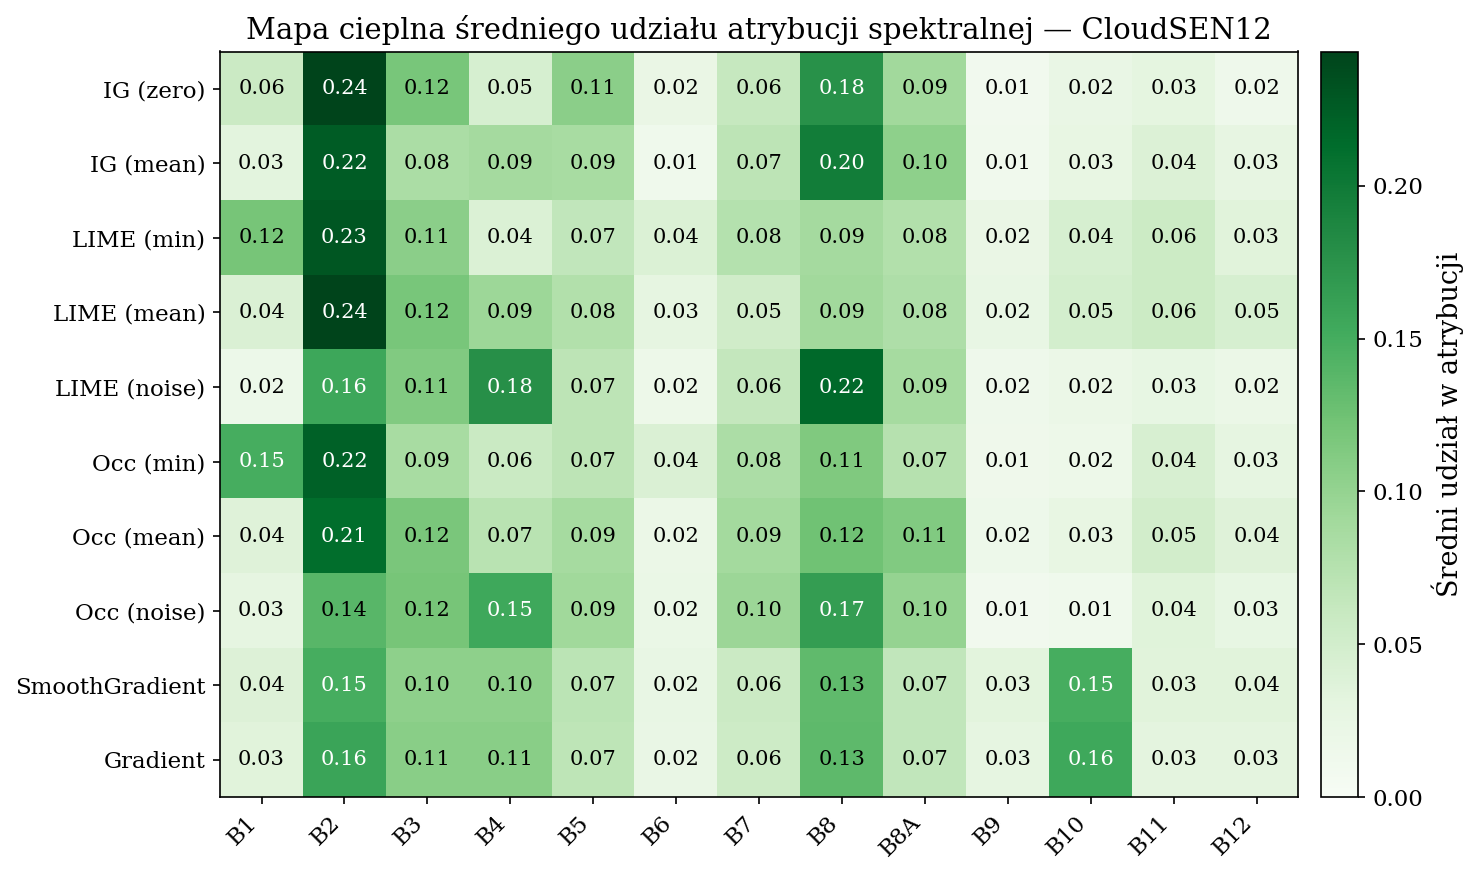

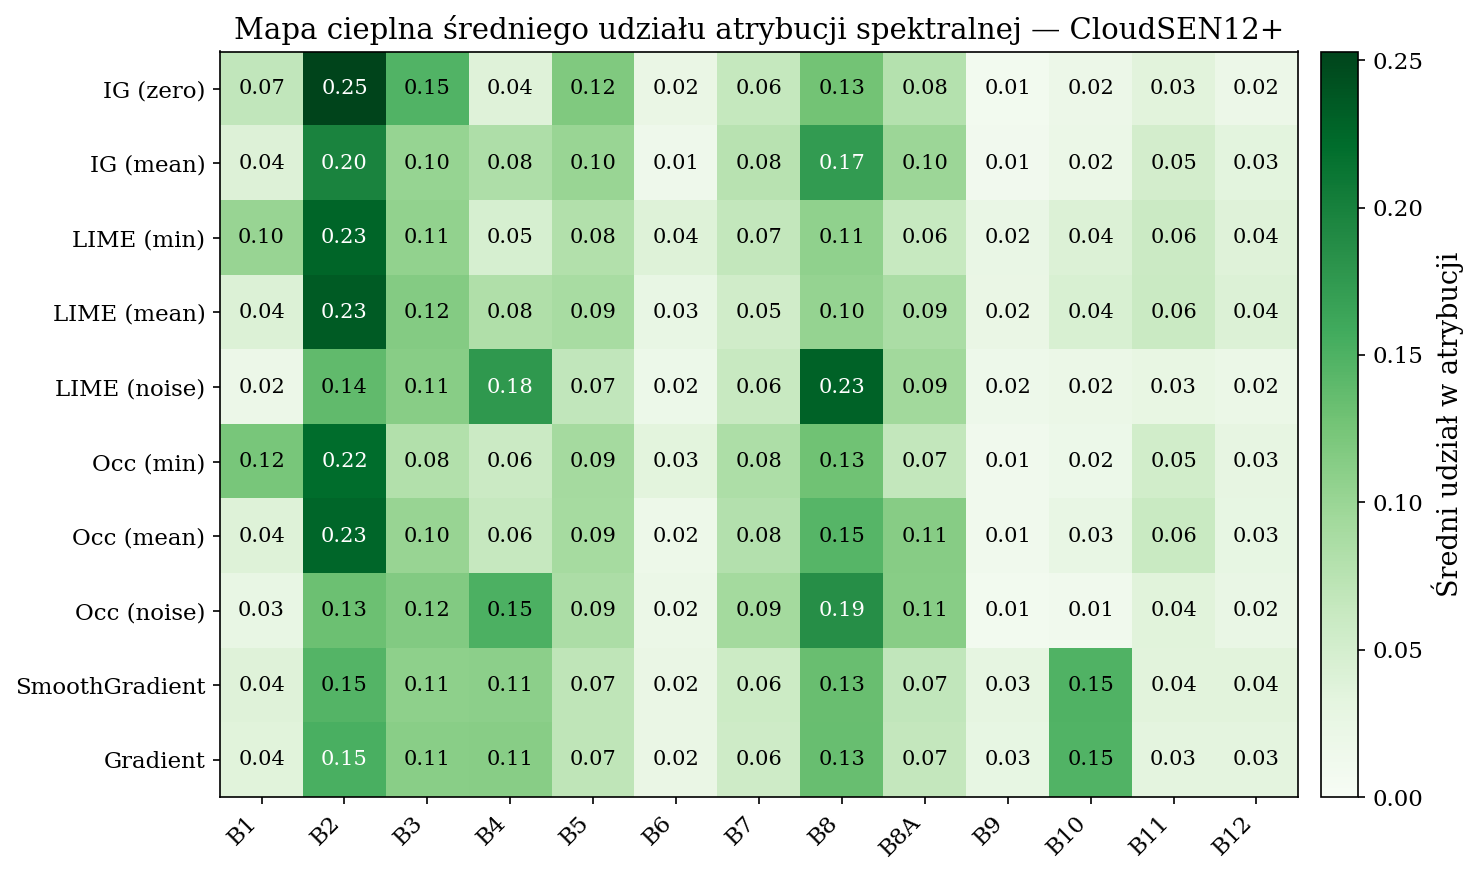

Generowanie słupków LIME...


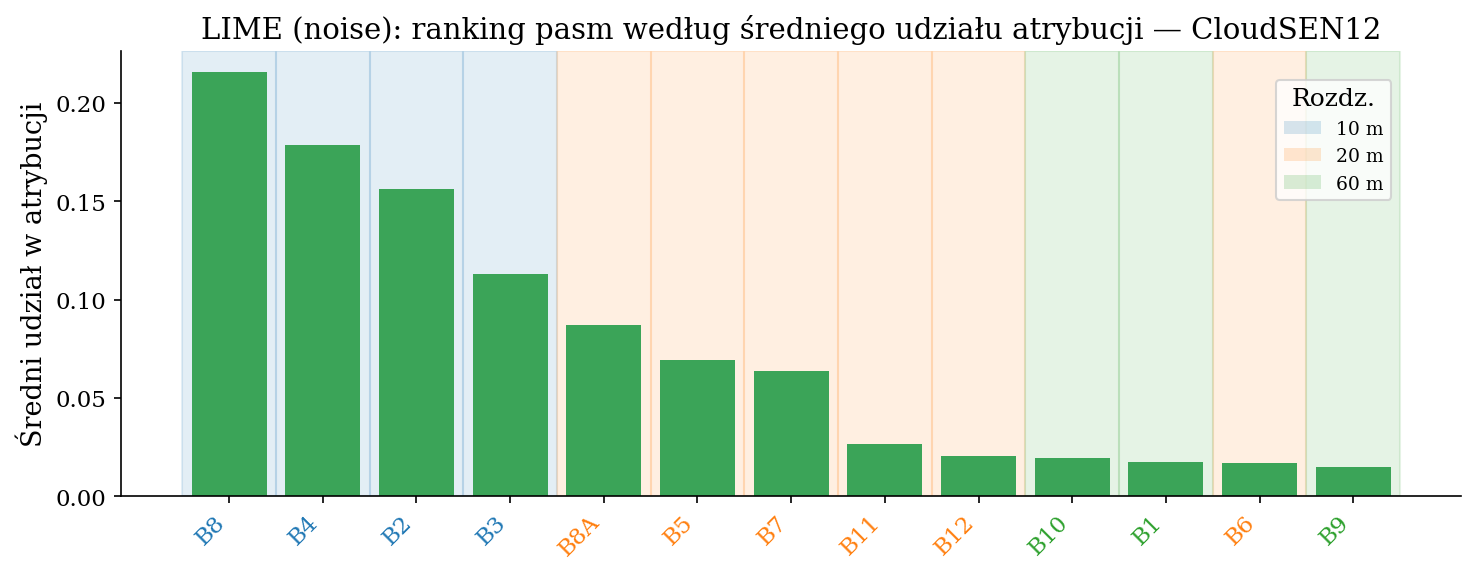

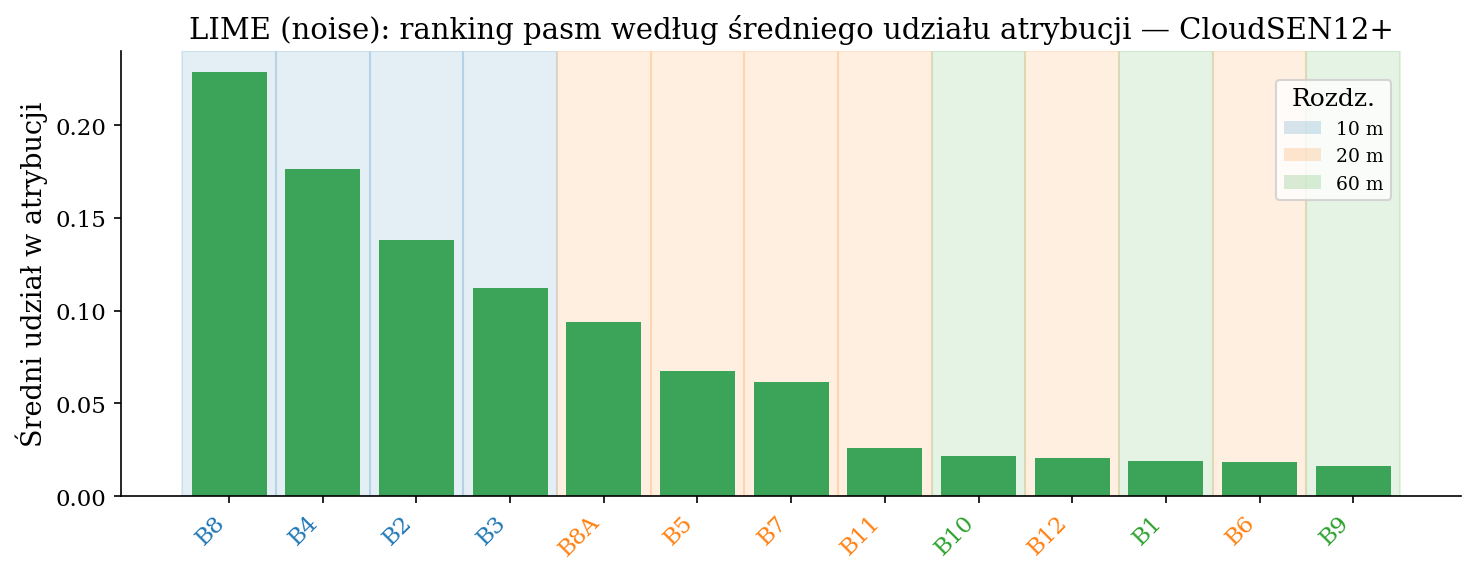

Generowanie wykresów grupowych...


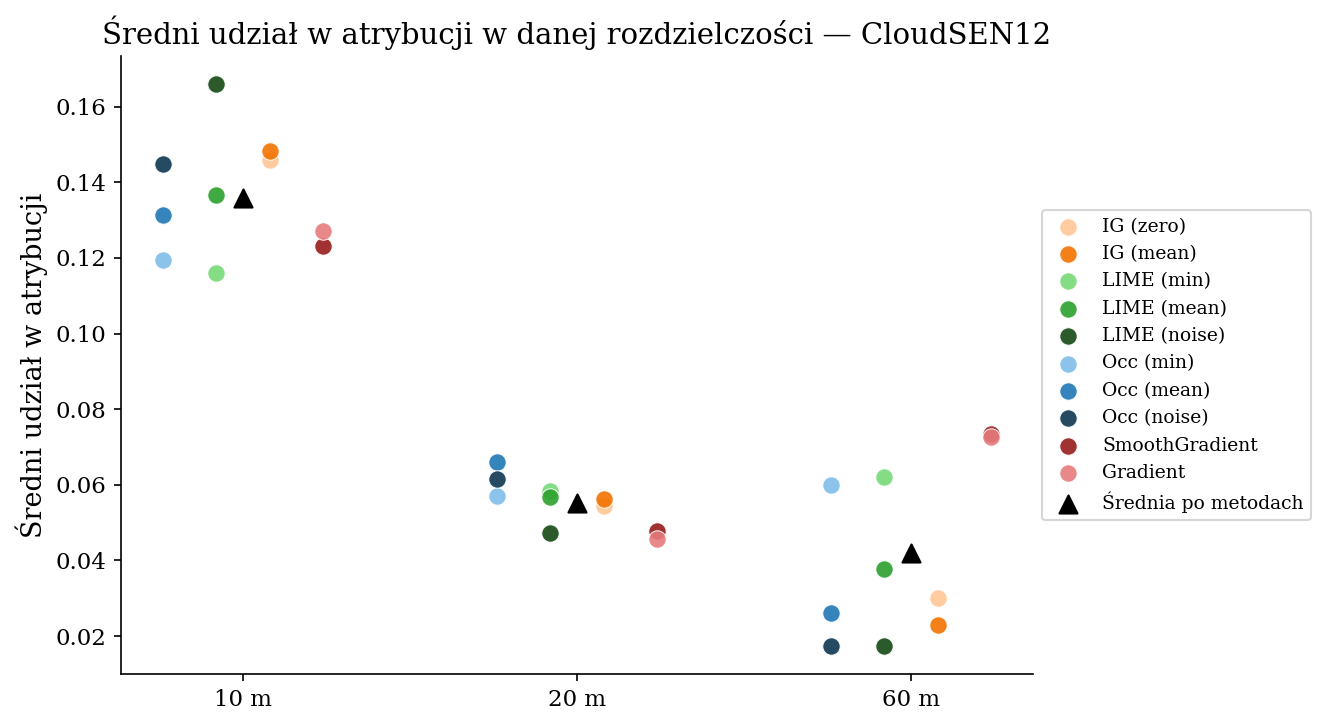

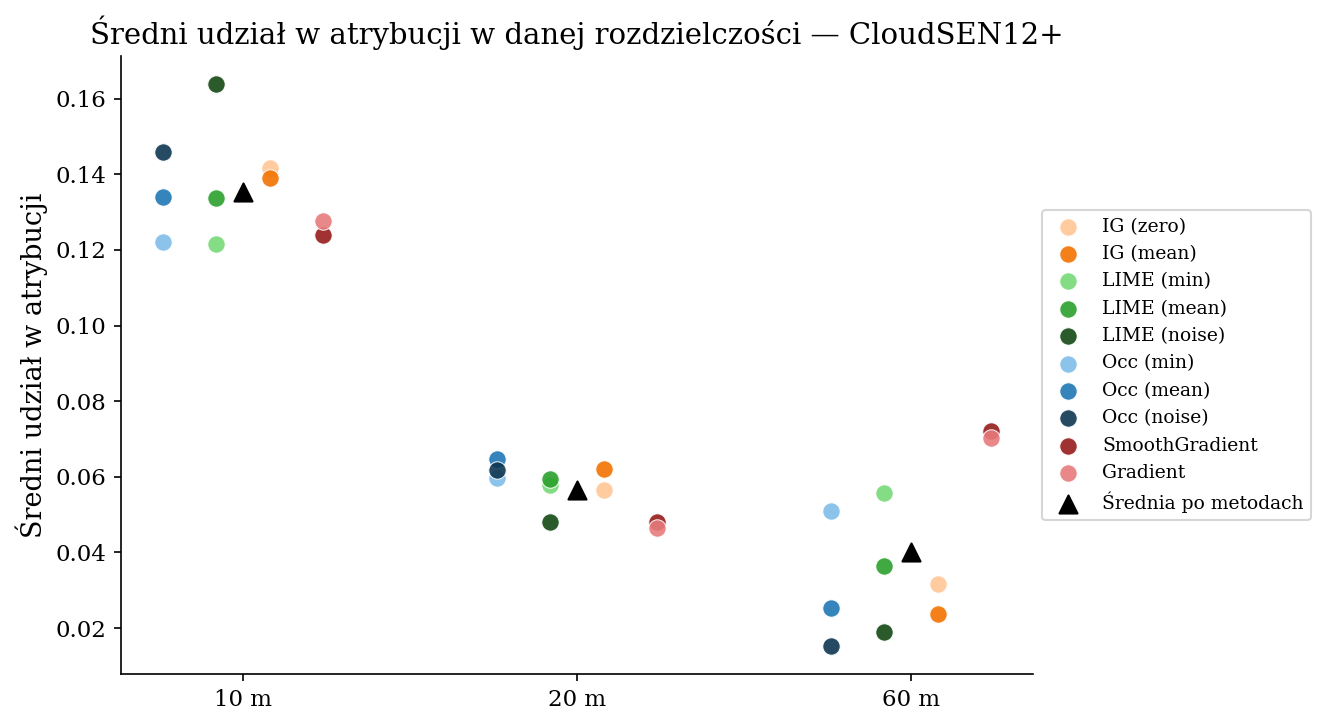

✔ Gotowe.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl
import os
import matplotlib.colors as mc
import colorsys
from matplotlib.patches import Patch

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "Latin Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


PATH_NO_PLUS = "df_xai/xai_cloudsen12"
PATH_PLUS    = "df_xai/xai_cloudsen12plus"


# scieżka do zapisu 

OUTDIR = ""
os.makedirs(OUTDIR, exist_ok=True)

band_labels = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B10","B11","B12"]

METHOD_LABEL = {
    "ig_0": "IG (zero)",
    "ig_mean": "IG (mean)",
    "lime_0": "LIME (min)",
    "lime_mean": "LIME (mean)",
    "lime_noise": "LIME (noise)",
    "reg_occ_0": "Occ (min)",
    "reg_occ_mean": "Occ (mean)",
    "reg_occ_noise": "Occ (noise)",
    "smoothgrad": "SmoothGradient",
    "vanilla_grad": "Gradient",
}
METHOD_ORDER = list(METHOD_LABEL.keys())
MEAN_ONLY_METHOD = "lime_noise"

BAND_GROUPS = {
    "10 m": ["B2", "B3", "B4", "B8"],
    "20 m": ["B5", "B6", "B7", "B8A", "B11", "B12"],
    "60 m": ["B1", "B9", "B10"],
}
BAND_TO_GROUP = {b: g for g, bands in BAND_GROUPS.items() for b in bands}

GROUP_BG_COLOR = {
    "10 m": "#1f77b4",
    "20 m": "#ff7f0e",
    "60 m": "#2ca02c",
}

FAMILY_BASE_COLOR = {
    "occ":  "#1f77b4",
    "lime": "#2ca02c",
    "ig":   "#ff7f0e",
    "grad": "#d62728",
}

METHOD_SHADE_FACTOR = {
    "reg_occ_0":     1.7,
    "reg_occ_mean":  1.0,
    "reg_occ_noise": 0.45,
    "lime_0":     1.65,
    "lime_mean":  1.0,
    "lime_noise": 0.45,
    "ig_0":    1.5,
    "ig_mean": 0.9,
    "vanilla_grad": 1.4,
    "smoothgrad":   0.7,
}

def adjust_lightness(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except Exception:
        c = color
    c = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(*c)
    new_l = max(0, min(1, amount * l))
    return colorsys.hls_to_rgb(h, new_l, s)

def _attr_idx(col: str) -> int:
    m = re.fullmatch(r"attr_c(\d+)", col)
    return int(m.group(1)) if m else 10**9

def load_and_normalize(path):
    df = pd.read_csv(path, low_memory=False)
    df = df[df["roi_type"] == "global"].copy()
    attr_cols = [c for c in df.columns if re.fullmatch(r"attr_c\d+", c)]
    attr_cols = sorted(attr_cols, key=_attr_idx)

    A = np.abs(df[attr_cols].to_numpy(float))
    A /= np.maximum(A.sum(axis=1, keepdims=True), 1e-12)
    df[attr_cols] = A

    band_to_attrcol = {band_labels[i]: attr_cols[i] for i in range(len(band_labels))}
    return df, attr_cols, band_to_attrcol

def plot_heatmap(df, attr_cols, dataset_name, outname, show=True):
    mean_all = df.groupby("method")[attr_cols].mean()
    methods_present = [m for m in METHOD_ORDER if m in mean_all.index]
    mean_all = mean_all.loc[methods_present]
    data = mean_all.to_numpy()

    fig, ax = plt.subplots(figsize=(10, 6))
    vmax = float(np.nanmax(data))
    im = ax.imshow(data, cmap="Greens", aspect="auto", vmin=0, vmax=vmax)

    ax.set_yticks(range(len(methods_present)))
    ax.set_yticklabels([METHOD_LABEL[m] for m in methods_present])
    ax.set_xticks(range(len(attr_cols)))
    ax.set_xticklabels(band_labels, rotation=45, ha="right")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=10,
                color="white" if val > 0.60 * vmax else "black"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Średni udział w atrybucji")
    ax.set_title(f"Mapa cieplna średniego udziału atrybucji spektralnej — {dataset_name}")

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, outname), bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

def plot_lime_bars(df, attr_cols, dataset_name, outname, show=True):
    if MEAN_ONLY_METHOD not in df["method"].unique():
        return

    vals = df[df["method"] == MEAN_ONLY_METHOD][attr_cols].mean().to_numpy()
    idx = np.argsort(vals)[::-1]
    bands_sorted = np.array(band_labels)[idx]
    vals_sorted  = vals[idx]
    groups_sorted = [BAND_TO_GROUP[b] for b in bands_sorted]

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(vals_sorted))

    for i, g in enumerate(groups_sorted):
        ax.axvspan(i - 0.5, i + 0.5, color=GROUP_BG_COLOR[g], alpha=0.12, zorder=0)

    ax.bar(x, vals_sorted, color=plt.cm.Greens(0.65), zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(bands_sorted, rotation=45, ha="right")
    ax.set_ylabel("Średni udział w atrybucji")
    ax.set_title(f"LIME (noise): ranking pasm według średniego udziału atrybucji — {dataset_name}")

    for tick, g in zip(ax.get_xticklabels(), groups_sorted):
        tick.set_color(GROUP_BG_COLOR[g])

    handles = [Patch(facecolor=GROUP_BG_COLOR[g], alpha=0.18, label=g) for g in ["10 m", "20 m", "60 m"]]
    ax.legend(handles=handles, title="Rozdz.", loc="upper right", bbox_to_anchor=(0.955, 0.955))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, outname), bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

def plot_resolution_groups(df, attr_cols, band_to_attrcol, dataset_name, outname, show=True):
    mean_all = df.groupby("method")[attr_cols].mean()
    methods_present = [m for m in METHOD_ORDER if m in mean_all.index]
    mean_all = mean_all.loc[methods_present]

    group_names = list(BAND_GROUPS.keys())
    group_attrcols = [[band_to_attrcol[b] for b in BAND_GROUPS[gname]] for gname in group_names]

    METHOD_FAMILY_MAP = {
        "reg_occ_0": "occ", "reg_occ_mean": "occ", "reg_occ_noise": "occ",
        "lime_0": "lime", "lime_mean": "lime", "lime_noise": "lime",
        "ig_0": "ig", "ig_mean": "ig",
        "vanilla_grad": "grad", "smoothgrad": "grad",
    }
    FAMILY_OFFSET = {"occ": -0.24, "lime": -0.08, "ig": +0.08, "grad": +0.24}

    n_methods = len(methods_present)
    n_groups = len(group_names)

    Y_point = np.zeros((n_methods, n_groups), dtype=float)
    for mi, m in enumerate(methods_present):
        row = mean_all.loc[m]
        for gi, cols in enumerate(group_attrcols):
            Y_point[mi, gi] = float(row[cols].mean())

    tri_mean = Y_point.mean(axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))
    x_base = np.arange(n_groups)

    for mi, m in enumerate(methods_present):
        fam = METHOD_FAMILY_MAP.get(m, "lime")
        base_color = FAMILY_BASE_COLOR.get(fam, "gray")
        shade_factor = METHOD_SHADE_FACTOR.get(m, 1.0)
        final_color = adjust_lightness(base_color, shade_factor)

        x = x_base + FAMILY_OFFSET.get(fam, 0.0)
        y = Y_point[mi, :]

        ax.scatter(
            x, y,
            s=70,
            color=final_color,
            alpha=0.9,
            label=METHOD_LABEL[m],
            zorder=3,
            edgecolors="white",
            linewidth=0.5
        )

    ax.scatter(
        x_base, tri_mean,
        marker="^",
        s=75,
        color="black",
        label="Średnia po metodach",
        zorder=6,
    )

    ax.set_xticks(x_base)
    ax.set_xticklabels(group_names, fontsize=11, color="black")
    ax.set_ylabel("Średni udział w atrybucji")
    ax.set_title(f"Średni udział w atrybucji w danej rozdzielczości — {dataset_name}")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(ncol=1, frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, outname), bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

df_no, attr_no, band_to_attr_no = load_and_normalize(PATH_NO_PLUS)
df_pl, attr_pl, band_to_attr_pl = load_and_normalize(PATH_PLUS)

plot_heatmap(df_no, attr_no, "CloudSEN12",  "heatmap_cloudsen12.pdf", show=True)
plot_heatmap(df_pl, attr_pl, "CloudSEN12+", "heatmap_cloudsen12plus.pdf", show=True)

plot_lime_bars(df_no, attr_no, "CloudSEN12",  "bar_lime_noise_cloudsen12.pdf", show=True)
plot_lime_bars(df_pl, attr_pl, "CloudSEN12+", "bar_lime_noise_cloudsen12plus.pdf", show=True)

plot_resolution_groups(df_no, attr_no, band_to_attr_no, "CloudSEN12",  "bands_resolution_cloudsen12.pdf", show=True)
plot_resolution_groups(df_pl, attr_pl, band_to_attr_pl, "CloudSEN12+", "bands_resolution_cloudsen12plus.pdf", show=True)
